In [34]:
import random
import networkx as nx
import matplotlib.pyplot as plt
import time
import pandas as pd

In [35]:
vertices = 20
results = []
graph_results = {}

In [36]:
def vertex_cover(vertex, cover):
    global min_cover

    if vertex > vertices:
        for start, end in edgel:
            if start not in cover and end not in cover:
                return

        if not min_cover or len(cover) < len(min_cover):
            min_cover = cover.copy()
        return

    vertex_cover(vertex + 1, cover + [vertex])
    vertex_cover(vertex + 1, cover)

In [37]:
def greedy_vertex_cover(graph):
    matching = []
    used = set()

    for start, end in graph.edges():
        if start not in used and end not in used:
            matching.append((start, end))
            used.add(start)
            used.add(end)

    vertex_cover = set()

    for start, end in matching:
        vertex_cover.add(start)
        vertex_cover.add(end)

    return matching, sorted(vertex_cover)

In [38]:
for edges in list(range(20, 181, 20)) + [190]:
    edgel = []

    while len(edgel) < edges:
        start = random.randint(1, vertices)
        end = random.randint(1, vertices)
        if start != end and [start, end] not in edgel and [end, start] not in edgel:
            edgel.append([start, end])

    file_name = "file_vc_" + str(edges) + ".txt"
    with open(file_name, "w") as file:
        for start, end in edgel:
            file.write(str(start) + "," + str(end) + "\n")

    graph = nx.Graph()

    with open(file_name, "r") as file:
        for line in file:
            start, end = line.strip().split(",")
            graph.add_edge(int(start), int(end))

    graph.add_nodes_from(range(1, vertices + 1))

    min_cover = []
    start_time = time.time()

    vertex_cover(1, [])

    end_time = time.time()
    bf_time = end_time - start_time

    bf_size = len(min_cover)
    start_time = time.time()
    matching, greedy_cover = greedy_vertex_cover(graph)
    end_time = time.time()
    greedy_time = end_time - start_time

    greedy_size = len(greedy_cover)
    approximation_factor = greedy_size / bf_size

    print("\nVertices :", vertices)
    print("Edges :", edges)
    print("Brute Force Size :", bf_size)
    print("Brute Force Time :", bf_time)
    print("Greedy Size :", greedy_size)
    print("Greedy Time :", greedy_time)
    print("Approximation Factor :", approximation_factor)

    results.append(["(" + str(vertices) + ", " + str(edges) + ")", bf_size, bf_time, greedy_size, greedy_time, approximation_factor])

    graph_results[edges] = {"graph": graph, "min_cover": min_cover.copy(), "bf_size": bf_size, "bf_time": bf_time, "matching": matching.copy(), "greedy_cover": greedy_cover.copy(), "greedy_size": greedy_size, "greedy_time": greedy_time, "approximation_factor": approximation_factor}


Vertices : 20
Edges : 20
Brute Force Size : 10
Brute Force Time : 1.3885948657989502
Greedy Size : 18
Greedy Time : 0.00011920928955078125
Approximation Factor : 1.8

Vertices : 20
Edges : 40
Brute Force Size : 11
Brute Force Time : 1.700103998184204
Greedy Size : 14
Greedy Time : 8.702278137207031e-05
Approximation Factor : 1.2727272727272727

Vertices : 20
Edges : 60
Brute Force Size : 12
Brute Force Time : 1.2083289623260498
Greedy Size : 18
Greedy Time : 9.036064147949219e-05
Approximation Factor : 1.5

Vertices : 20
Edges : 80
Brute Force Size : 14
Brute Force Time : 1.2047979831695557
Greedy Size : 20
Greedy Time : 9.393692016601562e-05
Approximation Factor : 1.4285714285714286

Vertices : 20
Edges : 100
Brute Force Size : 14
Brute Force Time : 1.2584314346313477
Greedy Size : 18
Greedy Time : 9.560585021972656e-05
Approximation Factor : 1.2857142857142858

Vertices : 20
Edges : 120
Brute Force Size : 15
Brute Force Time : 1.3251004219055176
Greedy Size : 18
Greedy Time : 9.6559

In [39]:
results_table = pd.DataFrame(results, columns=["(n,m)", "BF Size", "BF Time", "Greedy Size", "Greedy Time", "Approximation Factor"])

In [40]:
display(results_table)

,"(n,m)",BF Size,BF Time,Greedy Size,Greedy Time,Approximation Factor
0,"(20, 20)",10,1.388595,18,0.000119,1.800000
1,"(20, 40)",11,1.700104,14,0.000087,1.272727
2,"(20, 60)",12,1.208329,18,0.000090,1.500000
3,"(20, 80)",14,1.204798,20,0.000094,1.428571
4,"(20, 100)",14,1.258431,18,0.000096,1.285714
5,"(20, 120)",15,1.325100,18,0.000097,1.200000
6,"(20, 140)",16,1.472330,20,0.000145,1.250000
7,"(20, 160)",16,3.008678,20,0.000112,1.250000
8,"(20, 180)",17,1.197774,20,0.000113,1.176471
9,"(20, 190)",19,1.220878,20,0.000123,1.052632


In [41]:
results_table.to_csv("practical3_results.csv", index=False)
print("Results saved to practical3_results.csv")

Results saved to practical3_results.csv



----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 20
----------------------------------------------------------------------------------------------------


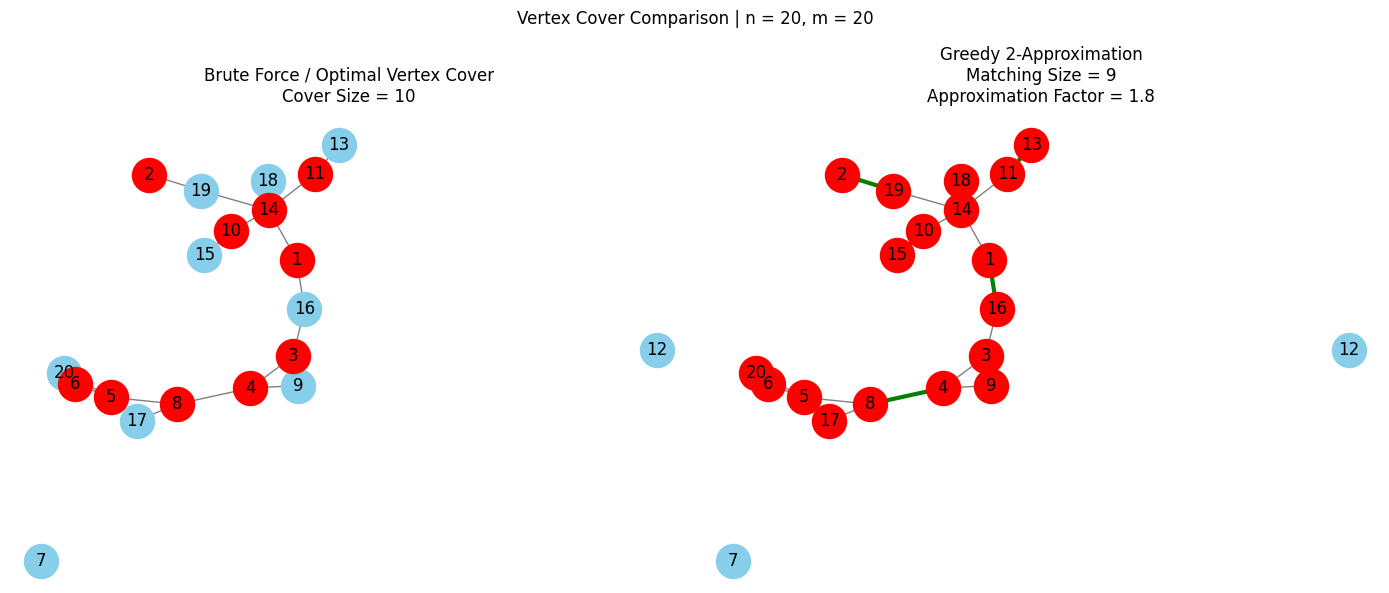


Brute Force:
Optimal Vertex Cover : [1, 2, 3, 4, 5, 6, 8, 10, 11, 14]
BF Size : 10
BF Time : 1.3885948657989502 seconds

Greedy Matching:
Matching : [(1, 16), (17, 5), (11, 13), (6, 20), (8, 4), (14, 18), (3, 9), (10, 15), (19, 2)]
Matching Size : 9

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 18
Greedy Time : 0.00011920928955078125 seconds

Approximation Factor : 1.8

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 40
----------------------------------------------------------------------------------------------------


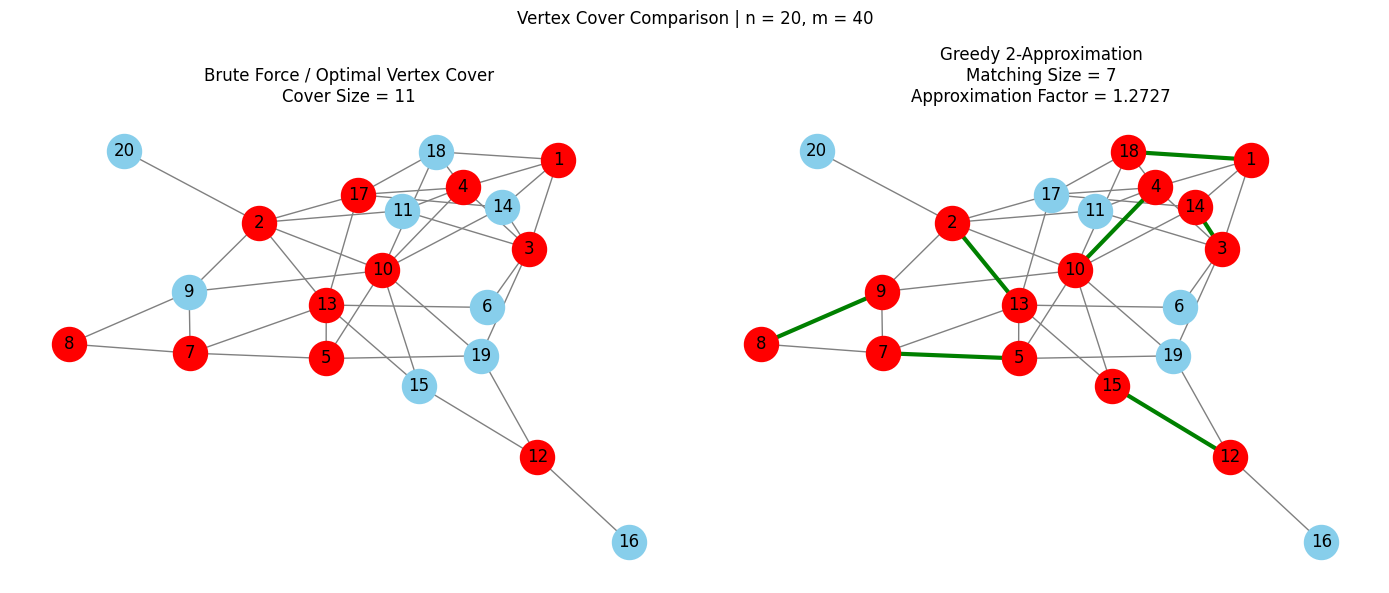


Brute Force:
Optimal Vertex Cover : [1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 17]
BF Size : 11
BF Time : 1.700103998184204 seconds

Greedy Matching:
Matching : [(4, 10), (13, 2), (5, 7), (3, 14), (12, 15), (1, 18), (9, 8)]
Matching Size : 7

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 18]
Greedy Size : 14
Greedy Time : 8.702278137207031e-05 seconds

Approximation Factor : 1.2727272727272727

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 60
----------------------------------------------------------------------------------------------------


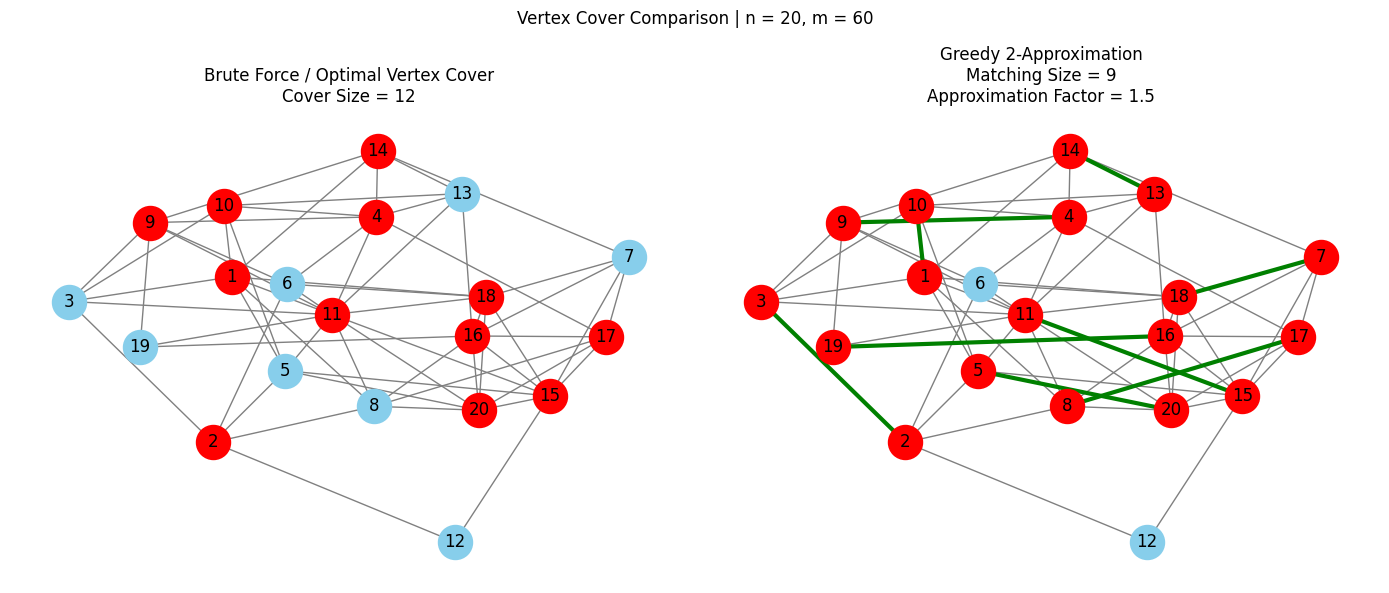


Brute Force:
Optimal Vertex Cover : [1, 2, 4, 9, 10, 11, 14, 15, 16, 17, 18, 20]
BF Size : 12
BF Time : 1.2083289623260498 seconds

Greedy Matching:
Matching : [(4, 9), (3, 2), (18, 7), (20, 5), (10, 1), (11, 15), (16, 19), (13, 14), (17, 8)]
Matching Size : 9

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 18
Greedy Time : 9.036064147949219e-05 seconds

Approximation Factor : 1.5

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 80
----------------------------------------------------------------------------------------------------


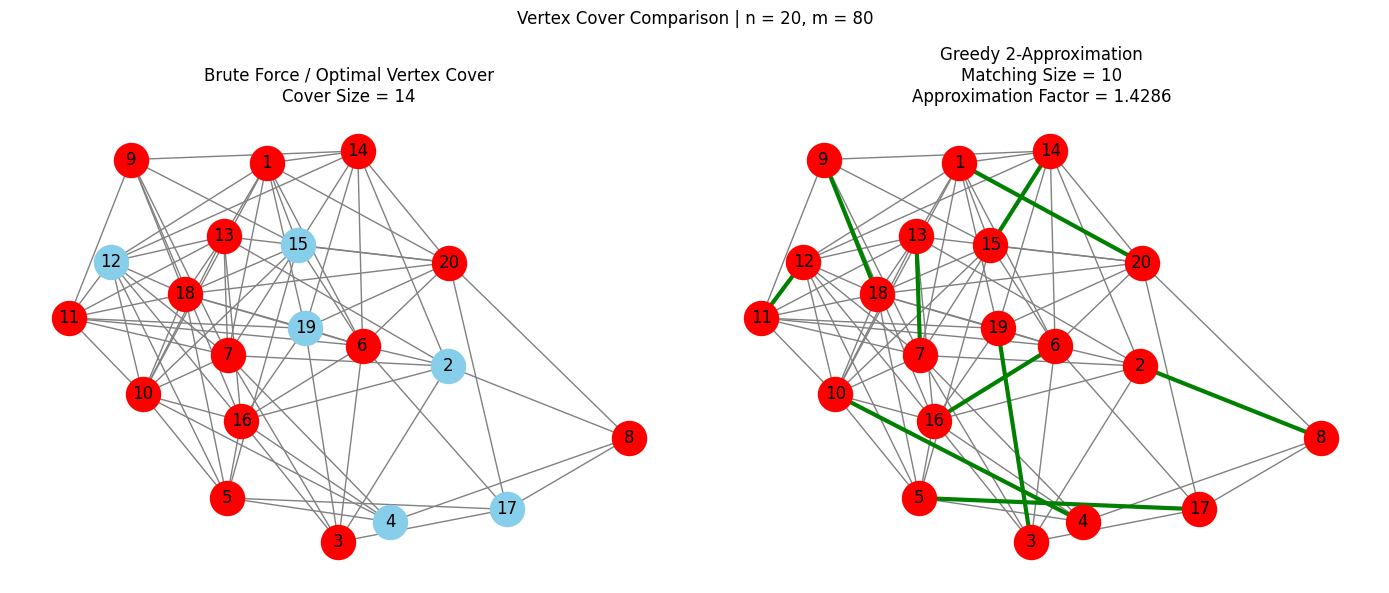


Brute Force:
Optimal Vertex Cover : [1, 3, 5, 6, 7, 8, 9, 10, 11, 13, 14, 16, 18, 20]
BF Size : 14
BF Time : 1.2047979831695557 seconds

Greedy Matching:
Matching : [(13, 7), (16, 6), (8, 2), (15, 14), (5, 17), (3, 19), (9, 18), (12, 11), (4, 10), (20, 1)]
Matching Size : 10

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 20
Greedy Time : 9.393692016601562e-05 seconds

Approximation Factor : 1.4285714285714286

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 100
----------------------------------------------------------------------------------------------------


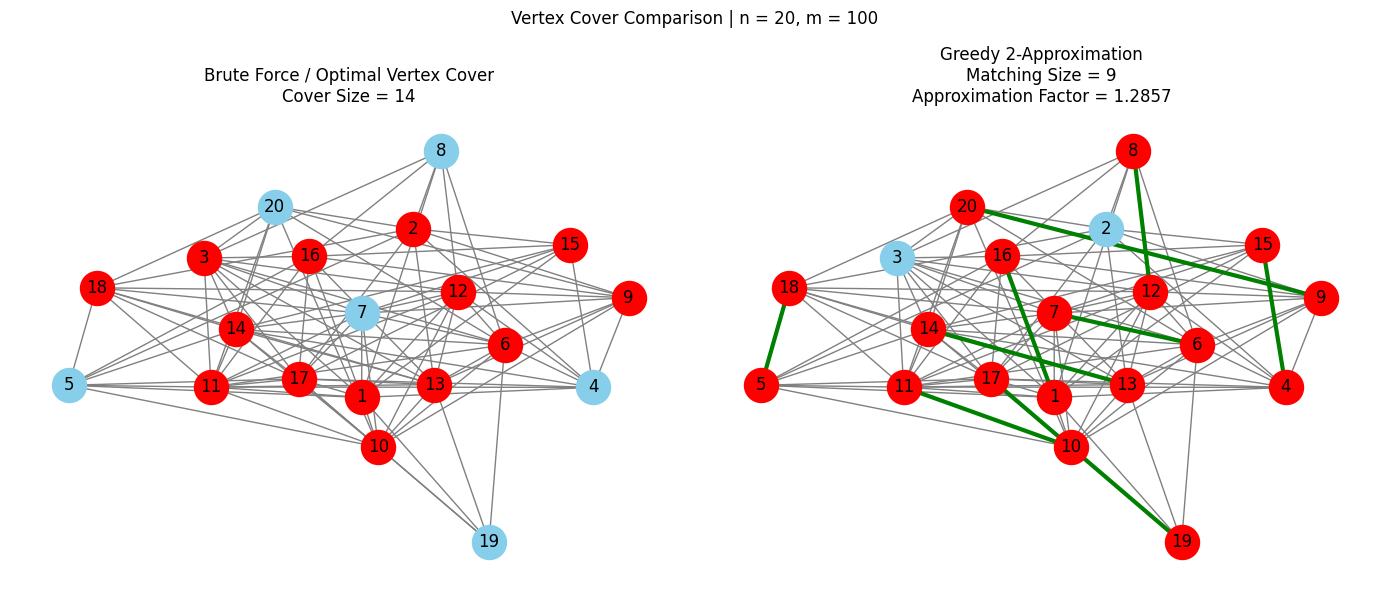


Brute Force:
Optimal Vertex Cover : [1, 2, 3, 6, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
BF Size : 14
BF Time : 1.2584314346313477 seconds

Greedy Matching:
Matching : [(20, 9), (1, 16), (8, 12), (14, 13), (18, 5), (19, 17), (6, 7), (11, 10), (4, 15)]
Matching Size : 9

Greedy:
Computed Vertex Cover : [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 18
Greedy Time : 9.560585021972656e-05 seconds

Approximation Factor : 1.2857142857142858

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 120
----------------------------------------------------------------------------------------------------


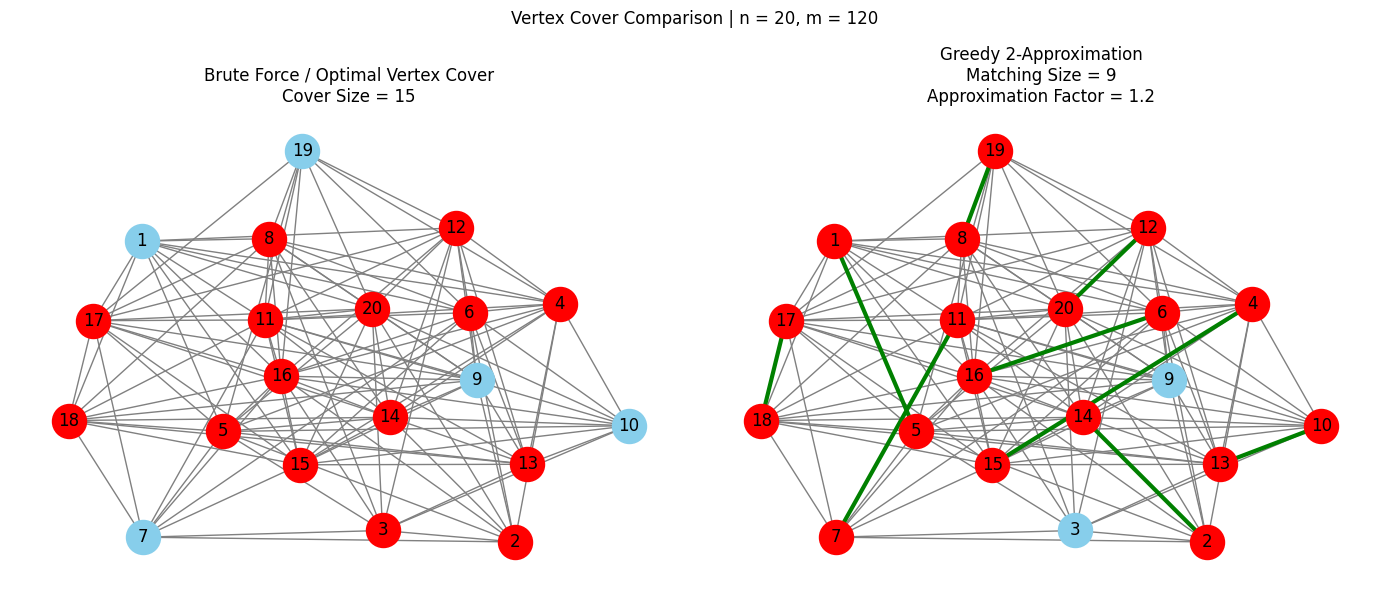


Brute Force:
Optimal Vertex Cover : [2, 3, 4, 5, 6, 8, 11, 12, 13, 14, 15, 16, 17, 18, 20]
BF Size : 15
BF Time : 1.3251004219055176 seconds

Greedy Matching:
Matching : [(19, 8), (5, 1), (4, 15), (20, 12), (16, 6), (7, 11), (10, 13), (18, 17), (14, 2)]
Matching Size : 9

Greedy:
Computed Vertex Cover : [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 18
Greedy Time : 9.655952453613281e-05 seconds

Approximation Factor : 1.2

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 140
----------------------------------------------------------------------------------------------------


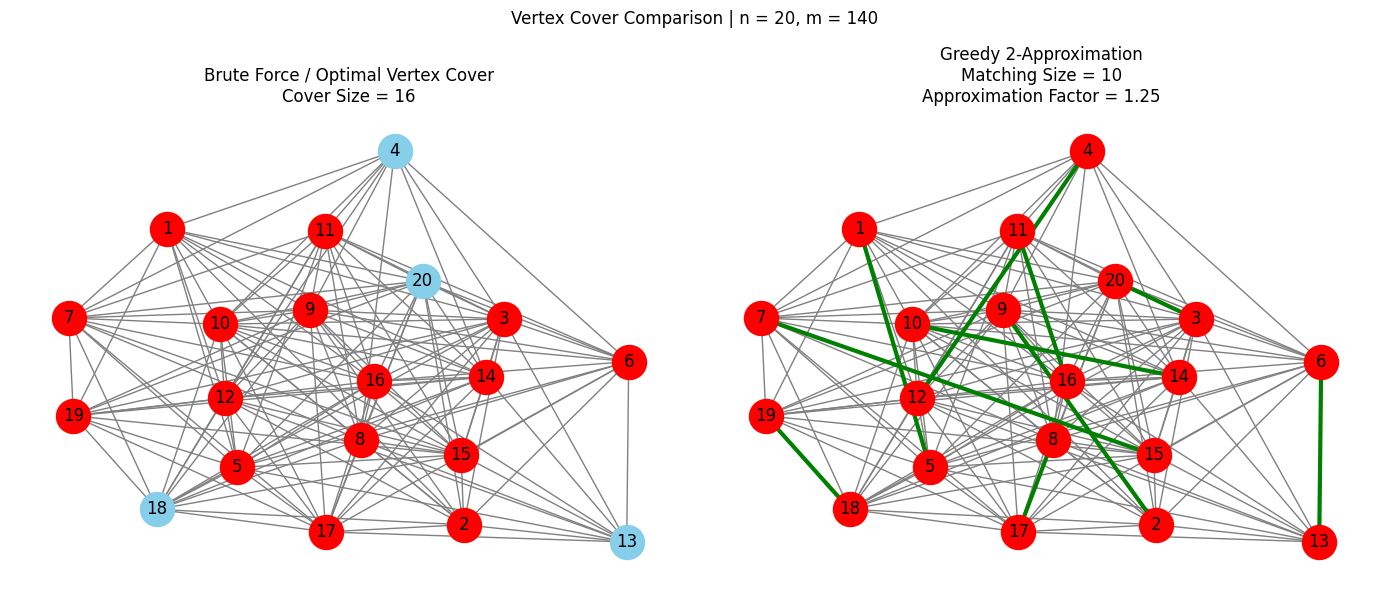


Brute Force:
Optimal Vertex Cover : [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 19]
BF Size : 16
BF Time : 1.472330093383789 seconds

Greedy Matching:
Matching : [(20, 3), (5, 1), (4, 12), (14, 10), (2, 9), (8, 17), (11, 16), (18, 19), (7, 15), (13, 6)]
Matching Size : 10

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 20
Greedy Time : 0.00014495849609375 seconds

Approximation Factor : 1.25

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 160
----------------------------------------------------------------------------------------------------


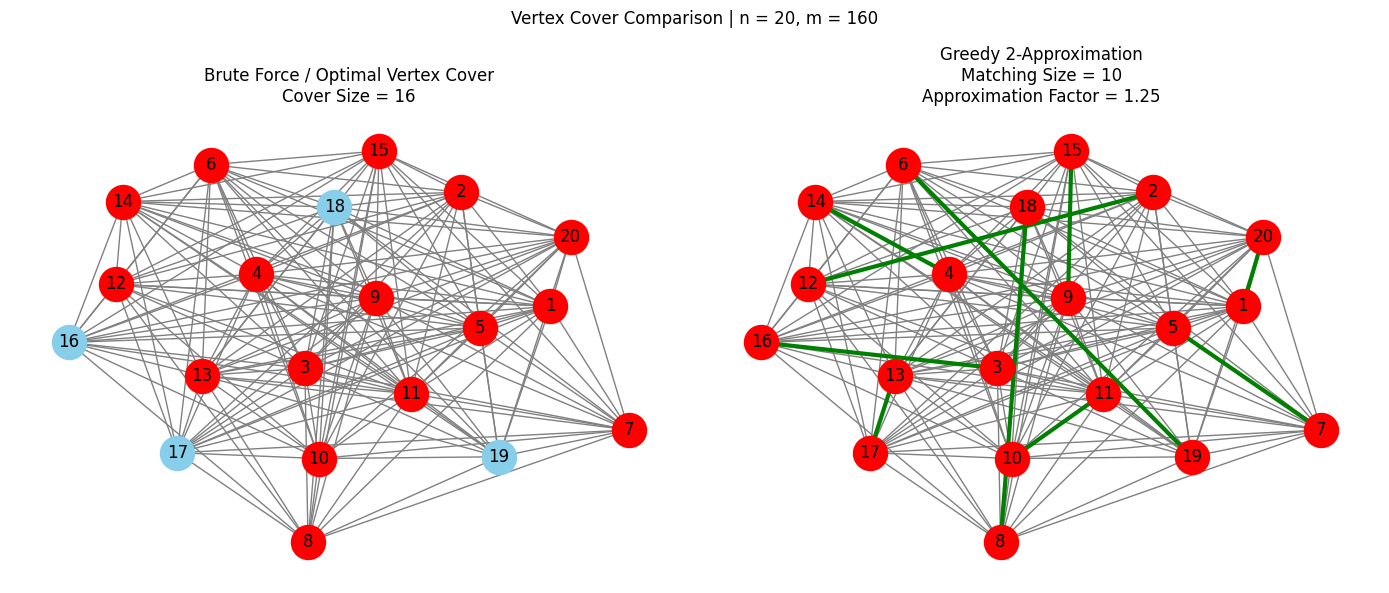


Brute Force:
Optimal Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20]
BF Size : 16
BF Time : 3.0086779594421387 seconds

Greedy Matching:
Matching : [(15, 9), (17, 13), (2, 12), (11, 10), (16, 3), (4, 14), (20, 1), (18, 8), (7, 5), (6, 19)]
Matching Size : 10

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 20
Greedy Time : 0.00011205673217773438 seconds

Approximation Factor : 1.25

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 180
----------------------------------------------------------------------------------------------------


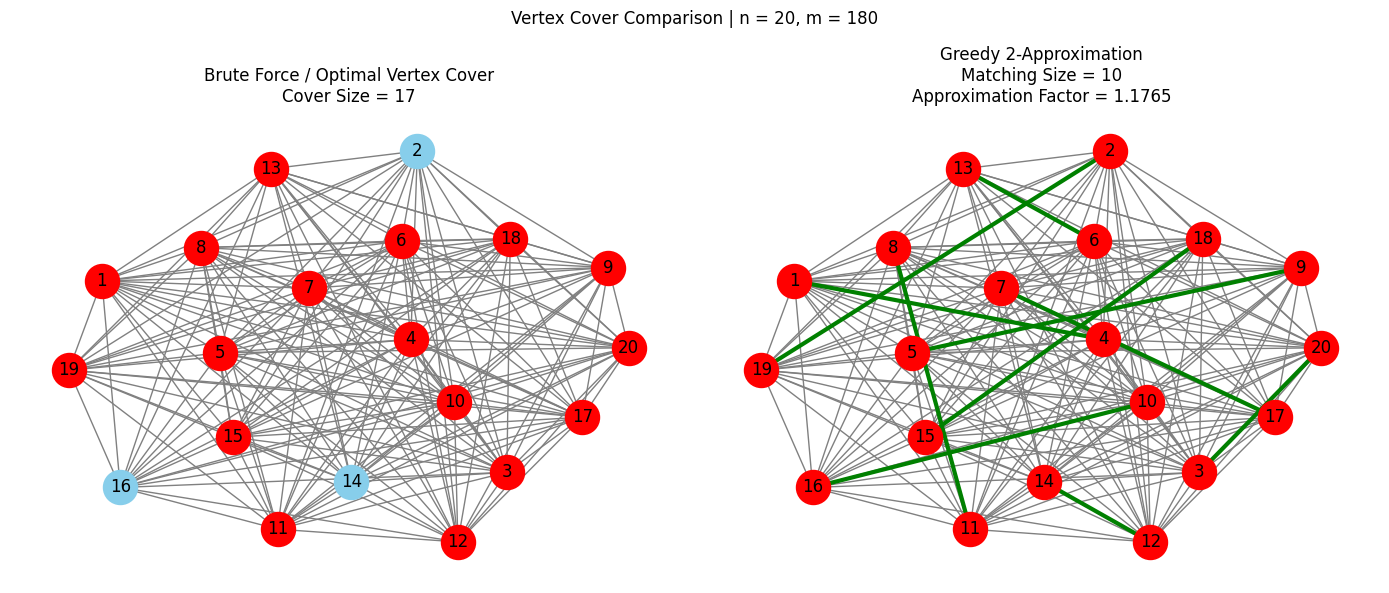


Brute Force:
Optimal Vertex Cover : [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17, 18, 19, 20]
BF Size : 17
BF Time : 1.1977744102478027 seconds

Greedy Matching:
Matching : [(6, 13), (11, 8), (18, 15), (7, 17), (1, 4), (19, 2), (10, 16), (14, 12), (3, 20), (9, 5)]
Matching Size : 10

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 20
Greedy Time : 0.00011324882507324219 seconds

Approximation Factor : 1.1764705882352942

----------------------------------------------------------------------------------------------------
Running experiment for n = 20 , m = 190
----------------------------------------------------------------------------------------------------


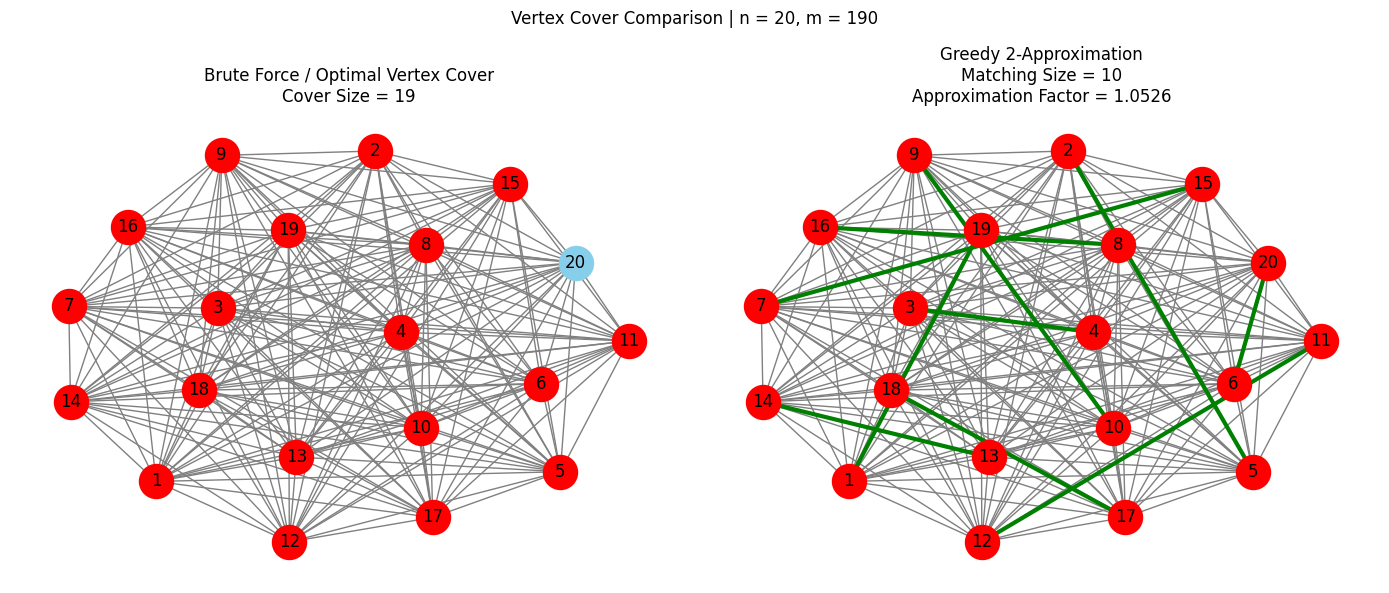


Brute Force:
Optimal Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
BF Size : 19
BF Time : 1.2208778858184814 seconds

Greedy Matching:
Matching : [(20, 6), (1, 19), (15, 7), (5, 2), (14, 13), (4, 3), (17, 18), (16, 8), (12, 11), (9, 10)]
Matching Size : 10

Greedy:
Computed Vertex Cover : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Greedy Size : 20
Greedy Time : 0.0001227855682373047 seconds

Approximation Factor : 1.0526315789473684


In [42]:
for edges in list(range(20, 181, 20)) + [190]:
    data = graph_results[edges]
    graph = data["graph"]
    min_cover = data["min_cover"]
    bf_size = data["bf_size"]
    bf_time = data["bf_time"]
    matching = data["matching"]
    greedy_cover = data["greedy_cover"]
    greedy_size = data["greedy_size"]
    greedy_time = data["greedy_time"]
    approximation_factor = data["approximation_factor"]

    print("\n" + "-" * 100)
    print("Running experiment for n =", vertices, ", m =", edges)
    print("-" * 100)

    pos = nx.spring_layout(graph, seed=42)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    nx.draw_networkx_edges(graph, pos, ax=axes[0], edge_color="gray")
    other_nodes = [node for node in graph.nodes() if node not in min_cover]
    nx.draw_networkx_nodes(graph, pos, nodelist=other_nodes, node_color="skyblue", node_size=600, ax=axes[0])
    nx.draw_networkx_nodes(graph, pos, nodelist=min_cover, node_color="red", node_size=600, ax=axes[0])
    nx.draw_networkx_labels(graph, pos, ax=axes[0])
    axes[0].set_title("Brute Force / Optimal Vertex Cover\n" + "Cover Size = " + str(bf_size))
    axes[0].axis("off")

    nx.draw_networkx_edges(graph, pos, ax=axes[1], edge_color="gray")
    other_nodes = [node for node in graph.nodes() if node not in greedy_cover]
    nx.draw_networkx_nodes(graph, pos, nodelist=other_nodes, node_color="skyblue", node_size=600, ax=axes[1])
    nx.draw_networkx_nodes(graph, pos, nodelist=greedy_cover, node_color="red", node_size=600, ax=axes[1])
    nx.draw_networkx_edges(graph, pos, edgelist=matching, edge_color="green", width=3, ax=axes[1])
    nx.draw_networkx_labels(graph, pos, ax=axes[1])

    axes[1].set_title("Greedy 2-Approximation\n" + "Matching Size = " + str(len(matching)) + "\nApproximation Factor = " + str(round(approximation_factor, 4)))
    axes[1].axis("off")

    plt.suptitle("Vertex Cover Comparison | n = " + str(vertices) + ", m = " + str(edges))
    plt.tight_layout()
    plt.show()

    print("\nBrute Force:")
    print("Optimal Vertex Cover :", min_cover)
    print("BF Size :", bf_size)
    print("BF Time :", bf_time, "seconds")
    print("\nGreedy Matching:")
    print("Matching :", matching)
    print("Matching Size :", len(matching))
    print("\nGreedy:")
    print("Computed Vertex Cover :", greedy_cover)
    print("Greedy Size :", greedy_size)
    print("Greedy Time :", greedy_time, "seconds")
    print("\nApproximation Factor :", approximation_factor)